In [1]:
import pandas as pd
titanic = pd.read_csv("https://peter.butka.website.tuke.sk/test/titanic2.csv")
titanic.head()

,pclass,survived,sex,age,sibsp,parch,ticket,fare,cabin,embarked,family,has_family,fare_ordinal,title,title_short,age_ordinal,deck
0,1,1,female,29.00,0,0,24160,211.3375,B5,Southampton,0,False,most expensive,Miss,Miss,adult,B
1,1,1,male,0.92,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Master,rare title,child,C
2,1,0,female,2.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Miss,Miss,child,C
3,1,0,male,30.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Mr,Mr,adult,C
4,1,0,female,25.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Mrs,Mrs,adult,C


<AxesSubplot:xlabel='survived', ylabel='Count'>

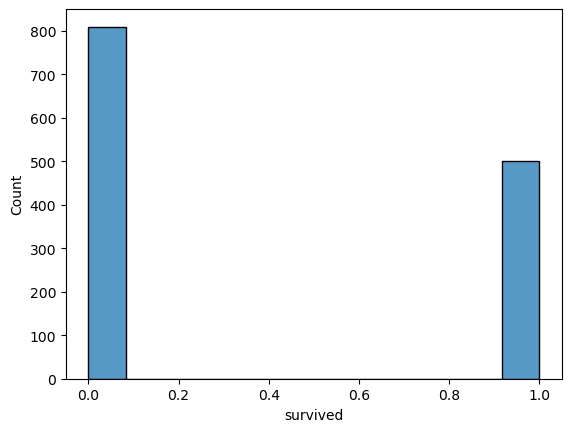

In [3]:
import seaborn as sns
sns.histplot(data=titanic, x="survived")

In [4]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
titanic['fare'] = scaler.fit_transform(titanic[['fare']])
titanic['age'] = scaler.fit_transform(titanic[['age']])


In [6]:
#train_data = titanic.sample(frac=0.7)
#test_data = titanic.drop(train_data.index)

In [8]:
from sklearn.model_selection import train_test_split
import numpy as np
X = np.array(titanic[['fare', 'age']])
y = np.array(titanic['survived'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 5)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [10]:
y_pred = knn.predict(X_test)
pd.crosstab(y_test, y_pred)

col_0,0,1
row_0,,
0,187,59
1,79,68


In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.76      0.73       246
           1       0.54      0.46      0.50       147

    accuracy                           0.65       393
   macro avg       0.62      0.61      0.61       393
weighted avg       0.64      0.65      0.64       393

